# lumerical_tuned_bs_EME.ipynb

Self-contained workflow:

1. Generate the same tuned directional-coupler beam-splitter GDS.
2. Add 20 um straight waveguide extension at each of the four layout ports.
3. Save to `gds/tuned_beam_splitter.gds`.
4. Open Lumerical MODE.
5. Import the GDS as 220 nm Si using Palik Si.
6. Add an EME region around the same geometry.
7. Use EME cell groups:
   - input straight section inside the EME region
   - left S-bend
   - uniform coupling section
   - right S-bend
   - output straight section inside the EME region
8. Run EME and extract the S-matrix.

Important EME convention:

- EME has one input boundary at `x min` and one output boundary at `x max`.
- The 2x2 directional coupler is represented by multiple modes on each EME boundary.
- Logical beam-splitter ports:
  - layout `o1` = EME left boundary, top waveguide mode
  - layout `o2` = EME left boundary, bottom waveguide mode
  - layout `o3` = EME right boundary, top waveguide mode
  - layout `o4` = EME right boundary, bottom waveguide mode

Units:

- gdsfactory layout units: um
- Lumerical script units: m

## Imports and paths

In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gdsfactory as gf

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
GDS_DIR = Path("gds")
GDS_DIR.mkdir(exist_ok=True)

gds_path = GDS_DIR / "tuned_beam_splitter.gds"
param_json_path = GDS_DIR / "tuned_beam_splitter_parameters.json"
eme_project_path = GDS_DIR / "lumerical_tuned_bs_EME.lms"
eme_results_csv_path = GDS_DIR / "lumerical_tuned_bs_EME_results.csv"

print(f"GDS folder:        {GDS_DIR.resolve()}")
print(f"GDS path:          {gds_path.resolve()}")
print(f"EME project path:  {eme_project_path.resolve()}")

GDS folder:        C:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Beam Splitter Simulation\gds
GDS path:          C:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Beam Splitter Simulation\gds\tuned_beam_splitter.gds
EME project path:  C:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Beam Splitter Simulation\gds\lumerical_tuned_bs_EME.lms


## Design parameters you import/change

In [2]:
# ------------------------------------------------------------
# Waveguide geometry
# ------------------------------------------------------------
wg_width_um = 0.500          # 300 nm
# wg_width_um = 0.500        # optional 500 nm case

gap_um = 0.150               # edge-to-edge gap in um

# Coupling length from supermode analysis
coupling_length_um = 11.960     # replace with your tuned L_50/50

pitch = 4                    # waveguide pitch in um

# ------------------------------------------------------------
# S-bend routing
# ------------------------------------------------------------
sbend_x_um = 25.0           # horizontal S-bend length
sbend_y_um = pitch/2 - gap_um/2 - wg_width_um/2  # vertical S-bend offset

# Straight waveguide extensions added at all four ports.
port_straight_um = 20.0

# ------------------------------------------------------------
# GDS layers
# ------------------------------------------------------------
WG_LAYER = (1, 0)
LABEL_LAYER = (10, 0)

# Polygon sampling
num_sbend_points = 151
num_straight_points = 40

print("Tuned beam splitter settings")
print("----------------------------")
print(f"wg_width_um         = {wg_width_um:.3f}")
print(f"gap_um              = {gap_um:.3f}")
print(f"coupling_length_um  = {coupling_length_um:.3f}")
print(f"sbend_x_um          = {sbend_x_um:.3f}")
print(f"sbend_y_um          = {sbend_y_um:.3f}")
print(f"port_straight_um    = {port_straight_um:.3f}")

Tuned beam splitter settings
----------------------------
wg_width_um         = 0.500
gap_um              = 0.150
coupling_length_um  = 11.960
sbend_x_um          = 25.000
sbend_y_um          = 1.675
port_straight_um    = 20.000


## Full GDS-generation code

In [3]:
def smoothstep(t: np.ndarray) -> np.ndarray:
    """
    Cubic smoothstep interpolation from 0 to 1.

    y(t) = 3t^2 - 2t^3

    This gives zero slope at both ends, which is good for S-bends.
    """
    return 3 * t**2 - 2 * t**3


def make_sbend_centerline(
    x0: float,
    x1: float,
    y0: float,
    y1: float,
    npoints: int = 151,
) -> tuple[np.ndarray, np.ndarray]:
    """Returns a smooth S-bend centerline between (x0, y0) and (x1, y1)."""
    t = np.linspace(0, 1, npoints)
    x = x0 + (x1 - x0) * t
    y = y0 + (y1 - y0) * smoothstep(t)
    return x, y


def make_straight_centerline(
    x0: float,
    x1: float,
    y: float,
    npoints: int = 40,
) -> tuple[np.ndarray, np.ndarray]:
    """Returns a straight centerline from x0 to x1 at fixed y."""
    x = np.linspace(x0, x1, npoints)
    yarr = np.full_like(x, y)
    return x, yarr


def centerline_to_polygon(
    x: np.ndarray,
    y: np.ndarray,
    width: float,
) -> list[tuple[float, float]]:
    """
    Converts a centerline into a waveguide polygon by offsetting
    the curve along the local normal direction.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(x) != len(y):
        raise ValueError("x and y must have the same length.")

    if len(x) < 2:
        raise ValueError("Centerline must have at least two points.")

    dx = np.gradient(x)
    dy = np.gradient(y)

    ds = np.sqrt(dx**2 + dy**2)
    if np.any(ds == 0):
        raise ValueError("Centerline contains repeated points.")

    nx = -dy / ds
    ny = dx / ds

    half_width = width / 2

    x_upper = x + half_width * nx
    y_upper = y + half_width * ny

    x_lower = x - half_width * nx
    y_lower = y - half_width * ny

    polygon_x = np.concatenate([x_upper, x_lower[::-1]])
    polygon_y = np.concatenate([y_upper, y_lower[::-1]])

    return list(zip(polygon_x, polygon_y))


def make_tuned_beam_splitter(
    wg_width: float = 0.5,
    gap: float = 0.15,
    coupling_length: float = 20.0,
    sbend_x: float = 40.0,
    sbend_y: float = 10.0,
    port_straight: float = 20.0,
    wg_layer: tuple[int, int] = (1, 0),
    label_layer: tuple[int, int] = (10, 0),
    num_sbend_points: int = 151,
    num_straight_points: int = 40,
    add_labels: bool = True,
) -> gf.Component:
    """
    Creates a 2x2 directional-coupler beam splitter with S-bend fanout.

    The port_straight parameter adds straight waveguide extensions
    of the same length at all four ports.
    """

    c = gf.Component("tuned_beam_splitter")

    # --------------------------------------------------------
    # Coupling-region vertical positions
    # --------------------------------------------------------
    center_sep = wg_width + gap

    y_top_coupler = +center_sep / 2
    y_bot_coupler = -center_sep / 2

    y_top_port = y_top_coupler + sbend_y
    y_bot_port = y_bot_coupler - sbend_y

    # --------------------------------------------------------
    # x positions
    # --------------------------------------------------------
    x_input = 0.0
    x_left_sbend_start = x_input + port_straight
    x_coupler_start = x_left_sbend_start + sbend_x
    x_coupler_end = x_coupler_start + coupling_length
    x_right_sbend_end = x_coupler_end + sbend_x
    x_output = x_right_sbend_end + port_straight

    # --------------------------------------------------------
    # Top waveguide
    # --------------------------------------------------------
    x1, y1 = make_straight_centerline(x_input, x_left_sbend_start, y_top_port, npoints=num_straight_points)
    x2, y2 = make_sbend_centerline(x_left_sbend_start, x_coupler_start, y_top_port, y_top_coupler, npoints=num_sbend_points)
    x3, y3 = make_straight_centerline(x_coupler_start, x_coupler_end, y_top_coupler, npoints=num_straight_points)
    x4, y4 = make_sbend_centerline(x_coupler_end, x_right_sbend_end, y_top_coupler, y_top_port, npoints=num_sbend_points)
    x5, y5 = make_straight_centerline(x_right_sbend_end, x_output, y_top_port, npoints=num_straight_points)

    x_top = np.concatenate([x1, x2[1:], x3[1:], x4[1:], x5[1:]])
    y_top = np.concatenate([y1, y2[1:], y3[1:], y4[1:], y5[1:]])

    # --------------------------------------------------------
    # Bottom waveguide
    # --------------------------------------------------------
    x1, y1 = make_straight_centerline(x_input, x_left_sbend_start, y_bot_port, npoints=num_straight_points)
    x2, y2 = make_sbend_centerline(x_left_sbend_start, x_coupler_start, y_bot_port, y_bot_coupler, npoints=num_sbend_points)
    x3, y3 = make_straight_centerline(x_coupler_start, x_coupler_end, y_bot_coupler, npoints=num_straight_points)
    x4, y4 = make_sbend_centerline(x_coupler_end, x_right_sbend_end, y_bot_coupler, y_bot_port, npoints=num_sbend_points)
    x5, y5 = make_straight_centerline(x_right_sbend_end, x_output, y_bot_port, npoints=num_straight_points)

    x_bot = np.concatenate([x1, x2[1:], x3[1:], x4[1:], x5[1:]])
    y_bot = np.concatenate([y1, y2[1:], y3[1:], y4[1:], y5[1:]])

    # --------------------------------------------------------
    # Add polygons
    # --------------------------------------------------------
    c.add_polygon(centerline_to_polygon(x_top, y_top, wg_width), layer=wg_layer)
    c.add_polygon(centerline_to_polygon(x_bot, y_bot, wg_width), layer=wg_layer)

    # --------------------------------------------------------
    # Add optical ports
    # --------------------------------------------------------
    c.add_port(name="o1", center=(x_input, y_top_port), width=wg_width, orientation=180, layer=wg_layer)
    c.add_port(name="o2", center=(x_input, y_bot_port), width=wg_width, orientation=180, layer=wg_layer)
    c.add_port(name="o3", center=(x_output, y_top_port), width=wg_width, orientation=0, layer=wg_layer)
    c.add_port(name="o4", center=(x_output, y_bot_port), width=wg_width, orientation=0, layer=wg_layer)

    # --------------------------------------------------------
    # Labels
    # --------------------------------------------------------
    if add_labels:
        label_offset_y = 1.0
        c.add_label(text="o1_in_top", position=(x_input, y_top_port + label_offset_y), layer=label_layer)
        c.add_label(text="o2_in_bot", position=(x_input, y_bot_port - label_offset_y), layer=label_layer)
        c.add_label(text="o3_out_top", position=(x_output, y_top_port + label_offset_y), layer=label_layer)
        c.add_label(text="o4_out_bot", position=(x_output, y_bot_port - label_offset_y), layer=label_layer)
        c.add_label(
            text=(
                f"DC_w{wg_width:.3f}_g{gap:.3f}_"
                f"Lc{coupling_length:.3f}_"
                f"Sx{sbend_x:.1f}_Sy{sbend_y:.1f}"
            ),
            position=(0.5 * x_output, 0.0),
            layer=label_layer,
        )

    # --------------------------------------------------------
    # Metadata
    # --------------------------------------------------------
    c.info["wg_width_um"] = wg_width
    c.info["gap_um"] = gap
    c.info["coupling_length_um"] = coupling_length
    c.info["sbend_x_um"] = sbend_x
    c.info["sbend_y_um"] = sbend_y
    c.info["port_straight_um"] = port_straight
    c.info["center_to_center_gap_um"] = center_sep
    c.info["coupling_region_pitch_um"] = center_sep
    c.info["input_output_pitch_um"] = abs(y_top_port - y_bot_port)
    c.info["total_length_um"] = x_output
    c.info["x_input_um"] = x_input
    c.info["x_left_sbend_start_um"] = x_left_sbend_start
    c.info["x_coupler_start_um"] = x_coupler_start
    c.info["x_coupler_end_um"] = x_coupler_end
    c.info["x_right_sbend_end_um"] = x_right_sbend_end
    c.info["x_output_um"] = x_output
    c.info["y_top_coupler_um"] = y_top_coupler
    c.info["y_bot_coupler_um"] = y_bot_coupler
    c.info["y_top_port_um"] = y_top_port
    c.info["y_bot_port_um"] = y_bot_port

    return c

## Generate and save the GDS

Saved tuned beam splitter GDS:
C:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Beam Splitter Simulation\gds\tuned_beam_splitter.gds

Saved parameter record:
C:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Beam Splitter Simulation\gds\tuned_beam_splitter_parameters.json

Component info:
wg_width_um                   : 0.5
gap_um                        : 0.15
coupling_length_um            : 11.96
sbend_x_um                    : 25.0
sbend_y_um                    : 1.675
port_straight_um              : 20.0
center_to_center_gap_um       : 0.65
coupling_region_pitch_um      : 0.65
input_output_pitch_um         : 4.0
total_length_um               : 101.96000000000001
x_input_um                    : 0.0
x_left_sbend_start_um         : 20.0
x_coupler_start_um            : 45.0
x_coupler_end_um              : 56.96
x_right_sbend_end_um          : 81.96000000000001
x_output_um                   : 101.96000000000001
y_top_coupler_um              : 0.325


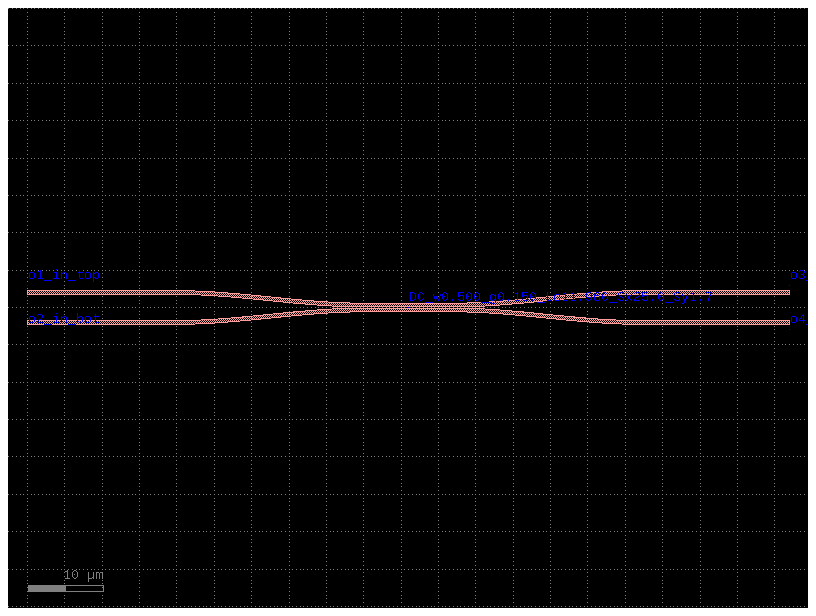

In [4]:
bs = make_tuned_beam_splitter(
    wg_width=wg_width_um,
    gap=gap_um,
    coupling_length=coupling_length_um,
    sbend_x=sbend_x_um,
    sbend_y=sbend_y_um,
    port_straight=port_straight_um,
    wg_layer=WG_LAYER,
    label_layer=LABEL_LAYER,
    num_sbend_points=num_sbend_points,
    num_straight_points=num_straight_points,
    add_labels=True,
)

bs.write_gds(gds_path)

# ------------------------------------------------------------
# Robust conversion of bs.info to a normal dictionary
# ------------------------------------------------------------
try:
    bs_info_dict = bs.info.model_dump()
except AttributeError:
    try:
        bs_info_dict = dict(bs.info)
    except TypeError:
        bs_info_dict = {}

param_record = {
    "component_name": bs.name,
    "gds_path": str(gds_path.resolve()),
    "wg_width_um": wg_width_um,
    "gap_um": gap_um,
    "coupling_length_um": coupling_length_um,
    "sbend_x_um": sbend_x_um,
    "sbend_y_um": sbend_y_um,
    "port_straight_um": port_straight_um,
    "wg_layer": WG_LAYER,
    "label_layer": LABEL_LAYER,
    "info": bs_info_dict,
}

with open(param_json_path, "w") as f:
    json.dump(param_record, f, indent=4)

print("Saved tuned beam splitter GDS:")
print(gds_path.resolve())

print("\nSaved parameter record:")
print(param_json_path.resolve())

print("\nComponent info:")
for key, value in bs_info_dict.items():
    print(f"{key:30s}: {value}")

bs.plot()

## Print port locations

In [5]:
print("Beam splitter ports")
print("-------------------")

port_dict = {}
for port in bs.ports:
    port_dict[port.name] = {
        "x_um": float(port.center[0]),
        "y_um": float(port.center[1]),
        "width_um": float(port.width),
        "orientation": float(port.orientation),
    }
    print(
        f"{port.name:3s} | center = ({port.center[0]:.3f}, {port.center[1]:.3f}) um "
        f"| width = {port.width:.3f} um "
        f"| orientation = {port.orientation}"
    )

Beam splitter ports
-------------------
o1  | center = (0.000, 2.000) um | width = 0.500 um | orientation = 180.0
o2  | center = (0.000, -2.000) um | width = 0.500 um | orientation = 180.0
o3  | center = (101.960, 2.000) um | width = 0.500 um | orientation = 0.0
o4  | center = (101.960, -2.000) um | width = 0.500 um | orientation = 0.0


## Locate and import lumapi

In [6]:
possible_lumapi_paths = [
    r"C:\Program Files\Lumerical\v261\api\python",
    r"C:\Program Files\Lumerical\v251\api\python",
    r"C:\Program Files\Lumerical\v242\api\python",
]

for p in possible_lumapi_paths:
    if Path(p).exists() and p not in sys.path:
        sys.path.append(p)
        print(f"Added lumapi path: {p}")

import lumapi

print("lumapi imported successfully.")

Added lumapi path: C:\Program Files\Lumerical\v261\api\python
lumapi imported successfully.


## Open Lumerical MODE for EME

In [7]:
mode = lumapi.MODE(hide=False)
print("Opened Lumerical MODE.")

Opened Lumerical MODE.


## Global Lumerical settings

In [8]:
lambda_fit_min_um = 1.2
lambda_fit_max_um = 1.7

lambda_sim_min_um = 1.5
lambda_sim_max_um = 1.6
lambda0_um = 1.55
num_wavelength_points = 101

si_thickness_um = 0.22

# z placement of silicon device layer
si_z_min_um = 0.0
si_z_max_um = si_z_min_um + si_thickness_um
si_z_center_um = 0.5 * (si_z_min_um + si_z_max_um)

# Material names in Lumerical material database.
# Use the fitted Palik material if you already created one, otherwise this uses the database Palik entry.
si_material_name = "Si (Silicon) - Palik"
sio2_material_name = "SiO2 (Glass) - Palik"

# GDS import settings
gds_top_cell = "tuned_beam_splitter"
gds_layer_string = "1:0"

print("Lumerical EME settings")
print("----------------------")
print(f"GDS file:              {gds_path.resolve()}")
print(f"Top cell:              {gds_top_cell}")
print(f"GDS layer:             {gds_layer_string}")
print(f"Si material:           {si_material_name}")
print(f"Si thickness:          {si_thickness_um:.3f} um")
print(f"Si z min/max:          {si_z_min_um:.3f} / {si_z_max_um:.3f} um")
print(f"Simulation wavelength: {lambda_sim_min_um:.3f} - {lambda_sim_max_um:.3f} um")
print(f"Material fit range:    {lambda_fit_min_um:.3f} - {lambda_fit_max_um:.3f} um")

Lumerical EME settings
----------------------
GDS file:              C:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Beam Splitter Simulation\gds\tuned_beam_splitter.gds
Top cell:              tuned_beam_splitter
GDS layer:             1:0
Si material:           Si (Silicon) - Palik
Si thickness:          0.220 um
Si z min/max:          0.000 / 0.220 um
Simulation wavelength: 1.500 - 1.600 um
Material fit range:    1.200 - 1.700 um


## Clear project and define script variables

In [9]:
mode.switchtolayout()
mode.deleteall()

# Lumerical script variables are in SI units.
mode.putv("lambda_fit_min", lambda_fit_min_um * 1e-6)
mode.putv("lambda_fit_max", lambda_fit_max_um * 1e-6)
mode.putv("lambda_sim_min", lambda_sim_min_um * 1e-6)
mode.putv("lambda_sim_max", lambda_sim_max_um * 1e-6)
mode.putv("lambda0", lambda0_um * 1e-6)

print("Cleared Lumerical MODE project.")

Cleared Lumerical MODE project.


## Add oxide cladding / BOX background

In [10]:
total_length_um = bs.info["total_length_um"]
input_output_pitch_um = bs.info["input_output_pitch_um"]

# Simulation padding around the GDS
x_padding_um = 0.0
y_padding_um = 10.0

x_min_um = -x_padding_um
x_max_um = total_length_um + x_padding_um

y_min_um = -input_output_pitch_um / 2 - y_padding_um
y_max_um = +input_output_pitch_um / 2 + y_padding_um

# Oxide thickness around Si.
# EME does not need huge z span, but keeping this box large is safe.
box_z_min_um = -3.0
box_z_max_um = +3.0

mode.putv("x_min", x_min_um * 1e-6)
mode.putv("x_max", x_max_um * 1e-6)
mode.putv("y_min", y_min_um * 1e-6)
mode.putv("y_max", y_max_um * 1e-6)
mode.putv("box_z_min", box_z_min_um * 1e-6)
mode.putv("box_z_max", box_z_max_um * 1e-6)

mode.eval(f"""
switchtolayout;

addrect;
set("name", "SiO2_cladding_box");
set("material", "{sio2_material_name}");
set("x min", x_min);
set("x max", x_max);
set("y min", y_min);
set("y max", y_max);
set("z min", box_z_min);
set("z max", box_z_max);
set("alpha", 0.15);
""")

print("Added SiO2 cladding box.")
print(f"x span: {x_min_um:.3f} to {x_max_um:.3f} um")
print(f"y span: {y_min_um:.3f} to {y_max_um:.3f} um")
print(f"z span: {box_z_min_um:.3f} to {box_z_max_um:.3f} um")

Added SiO2 cladding box.
x span: -0.000 to 101.960 um
y span: -12.000 to 12.000 um
z span: -3.000 to 3.000 um


## Import GDS into Lumerical as 220 nm Si

In [11]:
gds_file_lumerical = str(gds_path.resolve()).replace("\\", "/")

mode.putv("gds_file", gds_file_lumerical)
mode.putv("si_z_min", si_z_min_um * 1e-6)
mode.putv("si_z_max", si_z_max_um * 1e-6)

mode.eval(f"""
switchtolayout;

gdsimport(
    gds_file,
    "{gds_top_cell}",
    "{gds_layer_string}",
    "{si_material_name}",
    si_z_min,
    si_z_max
);
""")

print("Imported GDS into Lumerical MODE.")
print(f"Imported file: {gds_file_lumerical}")
print(f"Layer:         {gds_layer_string}")
print(f"Material:      {si_material_name}")
print(f"z min/max:     {si_z_min_um:.3f} / {si_z_max_um:.3f} um")

Imported GDS into Lumerical MODE.
Imported file: C:/Users/Amirali/Desktop/Beam_Splitter_Project/lumerical_simulations/Beam Splitter Simulation/gds/tuned_beam_splitter.gds
Layer:         1:0
Material:      Si (Silicon) - Palik
z min/max:     0.000 / 0.220 um


## Define EME region and cell-group geometry

In [12]:
# ------------------------------------------------------------
# EME x-span
# ------------------------------------------------------------
# The GDS has port_straight_um straight waveguide extensions.
# Put the EME boundary 5 um inside the straight section from each side.
# For port_straight_um = 20 um, this gives offset = 15 um from the physical GDS edge.
# ------------------------------------------------------------
port_offset_from_edge_um = port_straight_um - 5.0

x_left_eme_um = port_dict["o1"]["x_um"] + port_offset_from_edge_um
x_right_eme_um = port_dict["o3"]["x_um"] - port_offset_from_edge_um

# Internal geometry landmarks
x_left_sbend_start_um = bs.info["x_left_sbend_start_um"]
x_coupler_start_um = bs.info["x_coupler_start_um"]
x_coupler_end_um = bs.info["x_coupler_end_um"]
x_right_sbend_end_um = bs.info["x_right_sbend_end_um"]

# Cell group spans.
# Uniform coupling section needs only one cell. S-bends need multiple cells.
eme_span_left_straight_um = x_left_sbend_start_um - x_left_eme_um
eme_span_left_sbend_um = x_coupler_start_um - x_left_sbend_start_um
eme_span_coupler_um = x_coupler_end_um - x_coupler_start_um
eme_span_right_sbend_um = x_right_sbend_end_um - x_coupler_end_um
eme_span_right_straight_um = x_right_eme_um - x_right_sbend_end_um

eme_group_spans_um = np.array([
    eme_span_left_straight_um,
    eme_span_left_sbend_um,
    eme_span_coupler_um,
    eme_span_right_sbend_um,
    eme_span_right_straight_um,
], dtype=float)

# Number of cells per group.
# The coupler is longitudinally uniform, so 1 cell is enough there.
# Increase the S-bend cells if you see EME convergence issues.
eme_cells = np.array([1, 25, 1, 25, 1], dtype=int)

# Modes per cell group.
# Use at least 4 so top/bottom fundamental channels are both included.
# Use 8-12 for convergence check.
eme_modes = np.array([8, 8, 8, 8, 8], dtype=int)

# Transverse EME window.
eme_y_span_um = input_output_pitch_um + 8.0
eme_z_span_um = 3.0

eme_y_center_um = 0.0
eme_z_center_um = si_z_center_um

mode.putv("x_left_eme", x_left_eme_um * 1e-6)
mode.putv("x_right_eme", x_right_eme_um * 1e-6)
mode.putv("eme_y_center", eme_y_center_um * 1e-6)
mode.putv("eme_y_span", eme_y_span_um * 1e-6)
mode.putv("eme_z_center", eme_z_center_um * 1e-6)
mode.putv("eme_z_span", eme_z_span_um * 1e-6)
mode.putv("eme_group_spans", eme_group_spans_um * 1e-6)
mode.putv("eme_cells", eme_cells)
mode.putv("eme_modes", eme_modes)

print("EME region")
print("----------")
print(f"x_left_eme_um       = {x_left_eme_um:.3f}")
print(f"x_right_eme_um      = {x_right_eme_um:.3f}")
print(f"x span              = {x_right_eme_um - x_left_eme_um:.3f} um")
print(f"y center/span       = {eme_y_center_um:.3f} / {eme_y_span_um:.3f} um")
print(f"z center/span       = {eme_z_center_um:.3f} / {eme_z_span_um:.3f} um")
print("\nCell group spans [um]:", eme_group_spans_um)
print("Cells per group:       ", eme_cells)
print("Modes per group:       ", eme_modes)

EME region
----------
x_left_eme_um       = 15.000
x_right_eme_um      = 86.960
x span              = 71.960 um
y center/span       = 0.000 / 12.000 um
z center/span       = 0.110 / 3.000 um

Cell group spans [um]: [ 5.   25.   11.96 25.    5.  ]
Cells per group:        [ 1 25  1 25  1]
Modes per group:        [8 8 8 8 8]


## Add EME solver region

In [13]:
# Cell-group spans in meters
eme_group_spans_um = np.array([
    5.0,                  # input straight section inside EME
    sbend_x_um,            # left S-bend
    coupling_length_um,    # uniform coupling region
    sbend_x_um,            # right S-bend
    5.0,                  # output straight section inside EME
])

# Number of cells per group
# Uniform straight / coupling regions can use 1 cell.
# S-bends need multiple cells because the cross-section changes with x.
eme_cells = np.array([
    1,
    25,
    1,
    25,
    1,
])

# Number of modes kept in each cell group
eme_modes = 10

# ------------------------------------------------------------
# EME x min
# ------------------------------------------------------------
# Left S-bend starts after the 20 um input straight.
# EME starts 5 um before the S-bend.
eme_x_min_um = bs.info["x_left_sbend_start_um"] - 5.0

eme_y_center_um = 0.0
eme_y_span_um = input_output_pitch_um + 8.0

eme_z_center_um = 0.5 * (si_z_min_um + si_z_max_um)
eme_z_span_um = 4.0

mode.putv("eme_x_min", eme_x_min_um * 1e-6)

mode.putv("eme_group_spans", eme_group_spans_um * 1e-6)
mode.putv("eme_cells", eme_cells)
mode.putv("eme_modes", eme_modes)

mode.putv("eme_y_center", eme_y_center_um * 1e-6)
mode.putv("eme_y_span", eme_y_span_um * 1e-6)
mode.putv("eme_z_center", eme_z_center_um * 1e-6)
mode.putv("eme_z_span", eme_z_span_um * 1e-6)

mode.eval("""
switchtolayout;

addeme;

set("x min", eme_x_min);

set("y", eme_y_center);
set("y span", eme_y_span);
set("z", eme_z_center);
set("z span", eme_z_span);

set("y min bc", "PML");
set("y max bc", "PML");
set("z min bc", "PML");
set("z max bc", "PML");

set("wavelength", lambda0);

set("number of cell groups", length(eme_group_spans));
set("group spans", eme_group_spans);
set("cells", eme_cells);

# Do not set subcell method as a string.
# MODE expects this property as a matrix.
# Leave it at the default first.

set("number of modes for all cell groups", eme_modes);
""")

eme_x_max_um = eme_x_min_um + np.sum(eme_group_spans_um)

print("Added EME solver region.")
print(f"EME x min = {eme_x_min_um:.3f} um")
print(f"EME x max = {eme_x_max_um:.3f} um")
print("EME group spans [um]:", eme_group_spans_um)
print("EME cells:", eme_cells)
print("Modes per group:", eme_modes)

Added EME solver region.
EME x min = 15.000 um
EME x max = 86.960 um
EME group spans [um]: [ 5.   25.   11.96 25.    5.  ]
EME cells: [ 1 25  1 25  1]
Modes per group: 10


## Add optional EME mesh override near the Si layer

In [14]:
add_local_mesh = True

# ------------------------------------------------------------
# Mesh resolution
# ------------------------------------------------------------
# Start with 20 nm. For final convergence, test 15 nm or 10 nm.
mesh_dx_um = 0.02
mesh_dy_um = 0.02
mesh_dz_um = 0.02

# ------------------------------------------------------------
# Mesh z span
# ------------------------------------------------------------
# User-defined z span = 1 um, centered at the Si layer center.
mesh_z_span_um = 1.0
si_z_center_um = 0.5 * (si_z_min_um + si_z_max_um)

mesh_z_min_um = si_z_center_um - mesh_z_span_um / 2
mesh_z_max_um = si_z_center_um + mesh_z_span_um / 2

# ------------------------------------------------------------
# Mesh padding around waveguides
# ------------------------------------------------------------
port_mesh_y_padding_um = 0.5
sbend_mesh_y_padding_um = 0.5
coupler_mesh_x_padding_um = 0.0
coupler_mesh_y_padding_um = 0.8

# ------------------------------------------------------------
# Helper function
# ------------------------------------------------------------
def add_mesh_box(
    mode,
    name: str,
    x_min_um: float,
    x_max_um: float,
    y_min_um: float,
    y_max_um: float,
    z_min_um: float,
    z_max_um: float,
    dx_um: float,
    dy_um: float,
    dz_um: float,
):
    """
    Adds a rectangular mesh override box in Lumerical MODE.

    All inputs are in um.
    """

    mode.putv("mesh_x_min", x_min_um * 1e-6)
    mode.putv("mesh_x_max", x_max_um * 1e-6)
    mode.putv("mesh_y_min", y_min_um * 1e-6)
    mode.putv("mesh_y_max", y_max_um * 1e-6)
    mode.putv("mesh_z_min", z_min_um * 1e-6)
    mode.putv("mesh_z_max", z_max_um * 1e-6)

    mode.putv("mesh_dx", dx_um * 1e-6)
    mode.putv("mesh_dy", dy_um * 1e-6)
    mode.putv("mesh_dz", dz_um * 1e-6)

    mode.eval(f"""
    switchtolayout;

    addmesh;
    set("name", "{name}");

    set("x min", mesh_x_min);
    set("x max", mesh_x_max);
    set("y min", mesh_y_min);
    set("y max", mesh_y_max);
    set("z min", mesh_z_min);
    set("z max", mesh_z_max);

    set("override x mesh", 1);
    set("override y mesh", 1);
    set("override z mesh", 1);

    set("dx", mesh_dx);
    set("dy", mesh_dy);
    set("dz", mesh_dz);
    """)


if add_local_mesh:

    # --------------------------------------------------------
    # Geometry landmarks from the generated GDS
    # --------------------------------------------------------
    x_input_um = bs.info["x_input_um"]
    x_left_sbend_start_um = bs.info["x_left_sbend_start_um"]
    x_coupler_start_um = bs.info["x_coupler_start_um"]
    x_coupler_end_um = bs.info["x_coupler_end_um"]
    x_right_sbend_end_um = bs.info["x_right_sbend_end_um"]
    x_output_um = bs.info["x_output_um"]

    y_top_port_um = bs.info["y_top_port_um"]
    y_bot_port_um = bs.info["y_bot_port_um"]
    y_top_coupler_um = bs.info["y_top_coupler_um"]
    y_bot_coupler_um = bs.info["y_bot_coupler_um"]

    # --------------------------------------------------------
    # 1) Port mesh overrides
    # --------------------------------------------------------
    # Important:
    # The port mesh boxes continue along the straight waveguides until the S-bends.
    #
    # Left ports:
    #   from x_input_um to x_left_sbend_start_um
    #
    # Right ports:
    #   from x_right_sbend_end_um to x_output_um
    # --------------------------------------------------------

    # Left top port: o1
    add_mesh_box(
        mode=mode,
        name="mesh_port_o1_to_left_sbend",
        x_min_um=x_input_um,
        x_max_um=x_left_sbend_start_um,
        y_min_um=y_top_port_um - wg_width_um / 2 - port_mesh_y_padding_um,
        y_max_um=y_top_port_um + wg_width_um / 2 + port_mesh_y_padding_um,
        z_min_um=mesh_z_min_um,
        z_max_um=mesh_z_max_um,
        dx_um=mesh_dx_um,
        dy_um=mesh_dy_um,
        dz_um=mesh_dz_um,
    )

    # Left bottom port: o2
    add_mesh_box(
        mode=mode,
        name="mesh_port_o2_to_left_sbend",
        x_min_um=x_input_um,
        x_max_um=x_left_sbend_start_um,
        y_min_um=y_bot_port_um - wg_width_um / 2 - port_mesh_y_padding_um,
        y_max_um=y_bot_port_um + wg_width_um / 2 + port_mesh_y_padding_um,
        z_min_um=mesh_z_min_um,
        z_max_um=mesh_z_max_um,
        dx_um=mesh_dx_um,
        dy_um=mesh_dy_um,
        dz_um=mesh_dz_um,
    )

    # Right top port: o3
    add_mesh_box(
        mode=mode,
        name="mesh_port_o3_from_right_sbend",
        x_min_um=x_right_sbend_end_um,
        x_max_um=x_output_um,
        y_min_um=y_top_port_um - wg_width_um / 2 - port_mesh_y_padding_um,
        y_max_um=y_top_port_um + wg_width_um / 2 + port_mesh_y_padding_um,
        z_min_um=mesh_z_min_um,
        z_max_um=mesh_z_max_um,
        dx_um=mesh_dx_um,
        dy_um=mesh_dy_um,
        dz_um=mesh_dz_um,
    )

    # Right bottom port: o4
    add_mesh_box(
        mode=mode,
        name="mesh_port_o4_from_right_sbend",
        x_min_um=x_right_sbend_end_um,
        x_max_um=x_output_um,
        y_min_um=y_bot_port_um - wg_width_um / 2 - port_mesh_y_padding_um,
        y_max_um=y_bot_port_um + wg_width_um / 2 + port_mesh_y_padding_um,
        z_min_um=mesh_z_min_um,
        z_max_um=mesh_z_max_um,
        dx_um=mesh_dx_um,
        dy_um=mesh_dy_um,
        dz_um=mesh_dz_um,
    )

    # --------------------------------------------------------
    # 2) Mesh override around the left S-bends
    # --------------------------------------------------------
    y_min_sbend_um = min(
        y_top_port_um,
        y_bot_port_um,
        y_top_coupler_um,
        y_bot_coupler_um,
    ) - wg_width_um / 2 - sbend_mesh_y_padding_um

    y_max_sbend_um = max(
        y_top_port_um,
        y_bot_port_um,
        y_top_coupler_um,
        y_bot_coupler_um,
    ) + wg_width_um / 2 + sbend_mesh_y_padding_um

    add_mesh_box(
        mode=mode,
        name="mesh_left_sbends",
        x_min_um=x_left_sbend_start_um,
        x_max_um=x_coupler_start_um,
        y_min_um=y_min_sbend_um,
        y_max_um=y_max_sbend_um,
        z_min_um=mesh_z_min_um,
        z_max_um=mesh_z_max_um,
        dx_um=mesh_dx_um,
        dy_um=mesh_dy_um,
        dz_um=mesh_dz_um,
    )

    # --------------------------------------------------------
    # 3) Mesh override around the coupling region
    # --------------------------------------------------------
    coupler_y_min_um = y_bot_coupler_um - wg_width_um / 2 - coupler_mesh_y_padding_um
    coupler_y_max_um = y_top_coupler_um + wg_width_um / 2 + coupler_mesh_y_padding_um

    add_mesh_box(
        mode=mode,
        name="mesh_coupling_region",
        x_min_um=x_coupler_start_um - coupler_mesh_x_padding_um,
        x_max_um=x_coupler_end_um + coupler_mesh_x_padding_um,
        y_min_um=coupler_y_min_um,
        y_max_um=coupler_y_max_um,
        z_min_um=mesh_z_min_um,
        z_max_um=mesh_z_max_um,
        dx_um=mesh_dx_um,
        dy_um=mesh_dy_um,
        dz_um=mesh_dz_um,
    )

    # --------------------------------------------------------
    # 4) Mesh override around the right S-bends
    # --------------------------------------------------------
    add_mesh_box(
        mode=mode,
        name="mesh_right_sbends",
        x_min_um=x_coupler_end_um,
        x_max_um=x_right_sbend_end_um,
        y_min_um=y_min_sbend_um,
        y_max_um=y_max_sbend_um,
        z_min_um=mesh_z_min_um,
        z_max_um=mesh_z_max_um,
        dx_um=mesh_dx_um,
        dy_um=mesh_dy_um,
        dz_um=mesh_dz_um,
    )

    print("Added local mesh overrides:")
    print("---------------------------")
    print("Port straight mesh boxes:")
    print("  mesh_port_o1_to_left_sbend")
    print("  mesh_port_o2_to_left_sbend")
    print("  mesh_port_o3_from_right_sbend")
    print("  mesh_port_o4_from_right_sbend")
    print()
    print("S-bend mesh boxes:")
    print("  mesh_left_sbends")
    print("  mesh_right_sbends")
    print()
    print("Coupling-region mesh box:")
    print("  mesh_coupling_region")
    print()
    print(f"dx, dy, dz = {mesh_dx_um:.3f}, {mesh_dy_um:.3f}, {mesh_dz_um:.3f} um")
    print(f"z mesh span = {mesh_z_span_um:.3f} um")
    print(f"z mesh min/max = {mesh_z_min_um:.3f} / {mesh_z_max_um:.3f} um")

else:
    print("Skipped local mesh overrides.")

Added local mesh overrides:
---------------------------
Port straight mesh boxes:
  mesh_port_o1_to_left_sbend
  mesh_port_o2_to_left_sbend
  mesh_port_o3_from_right_sbend
  mesh_port_o4_from_right_sbend

S-bend mesh boxes:
  mesh_left_sbends
  mesh_right_sbends

Coupling-region mesh box:
  mesh_coupling_region

dx, dy, dz = 0.020, 0.020, 0.020 um
z mesh span = 1.000 um
z mesh min/max = -0.390 / 0.610 um


## Define EME port positions

In [15]:
port_dict = {}

for port in bs.ports:
    port_dict[port.name] = {
        "x_um": float(port.center[0]),
        "y_um": float(port.center[1]),
        "width_um": float(port.width),
        "orientation": float(port.orientation),
    }

print("Port dictionary")
print("---------------")
for name, p in port_dict.items():
    print(
        f"{name:3s}: x = {p['x_um']:.3f} um, "
        f"y = {p['y_um']:.3f} um, "
        f"width = {p['width_um']:.3f} um, "
        f"orientation = {p['orientation']:.0f}"
    )

# ------------------------------------------------------------
# Explicit physical EME port mapping
# ------------------------------------------------------------
# Desired mapping:
#
#   port 1: left  top    y = +2 um
#   port 2: right top    y = +2 um
#   port 3: right bottom y = -2 um
#   port 4: left  bottom y = -2 um
#
# This means:
#   port 2 is in front of port 1
#   port 3 is in front of port 4
# ------------------------------------------------------------

y_port_1_um = +2.0   # left top
y_port_2_um = +2.0   # right top
y_port_3_um = -2.0   # right bottom
y_port_4_um = -2.0   # left bottom

# EME ports sit on the left/right boundaries.
# Use local windows around each waveguide.
eme_port_y_span_um = 3.0
eme_port_z_span_um = 3.0

si_z_center_um = 0.5 * (si_z_min_um + si_z_max_um)

mode.putv("y_port_1", y_port_1_um * 1e-6)
mode.putv("y_port_2", y_port_2_um * 1e-6)
mode.putv("y_port_3", y_port_3_um * 1e-6)
mode.putv("y_port_4", y_port_4_um * 1e-6)

mode.putv("eme_port_y_span", eme_port_y_span_um * 1e-6)
mode.putv("eme_port_z_span", eme_port_z_span_um * 1e-6)
mode.putv("si_z_center", si_z_center_um * 1e-6)

print("\nEME port positions")
print("------------------")
print(f"port 1: left  top    y = {y_port_1_um:.3f} um")
print(f"port 2: right top    y = {y_port_2_um:.3f} um")
print(f"port 3: right bottom y = {y_port_3_um:.3f} um")
print(f"port 4: left  bottom y = {y_port_4_um:.3f} um")
print(f"eme_port_y_span_um = {eme_port_y_span_um:.3f}")
print(f"eme_port_z_span_um = {eme_port_z_span_um:.3f}")
print(f"si_z_center_um     = {si_z_center_um:.3f}")

Port dictionary
---------------
o1 : x = 0.000 um, y = 2.000 um, width = 0.500 um, orientation = 180
o2 : x = 0.000 um, y = -2.000 um, width = 0.500 um, orientation = 180
o3 : x = 101.960 um, y = 2.000 um, width = 0.500 um, orientation = 0
o4 : x = 101.960 um, y = -2.000 um, width = 0.500 um, orientation = 0

EME port positions
------------------
port 1: left  top    y = 2.000 um
port 2: right top    y = 2.000 um
port 3: right bottom y = -2.000 um
port 4: left  bottom y = -2.000 um
eme_port_y_span_um = 3.000
eme_port_z_span_um = 3.000
si_z_center_um     = 0.110


## Define 4 physical EME ports

In [16]:
# Desired mapping:
#
#   port_1 = left  top    y = +2 um
#   port_2 = right top    y = +2 um
#   port_3 = right bottom y = -2 um
#   port_4 = left  bottom y = -2 um
#
# Important:
# port_1 and port_2 already exist by default.
# We do NOT delete them.

eme_port_y_span_um = 3.0
eme_port_z_span_um = 3.0

si_z_center_um = 0.5 * (si_z_min_um + si_z_max_um)

y_port_1_um = +2.0   # left top
y_port_2_um = +2.0   # right top
y_port_3_um = -2.0   # right bottom
y_port_4_um = -2.0   # left bottom

mode.putv("y_port_1", y_port_1_um * 1e-6)
mode.putv("y_port_2", y_port_2_um * 1e-6)
mode.putv("y_port_3", y_port_3_um * 1e-6)
mode.putv("y_port_4", y_port_4_um * 1e-6)

mode.putv("eme_port_y_span", eme_port_y_span_um * 1e-6)
mode.putv("eme_port_z_span", eme_port_z_span_um * 1e-6)
mode.putv("si_z_center", si_z_center_um * 1e-6)

mode.eval("""
switchtolayout;
setactivesolver("EME");

# ------------------------------------------------------------
# Configure existing port_1: left top, y = +2 um
# ------------------------------------------------------------
select("EME::Ports::port_1");

# port_1 is already the left default EME port.
# Do not change the name.
set("use full simulation span", 0);

set("y", y_port_1);
set("y span", eme_port_y_span);

set("z", si_z_center);
set("z span", eme_port_z_span);

# ------------------------------------------------------------
# Configure existing port_2: right top, y = +2 um
# ------------------------------------------------------------
select("EME::Ports::port_2");

# port_2 is already the right default EME port.
# Do not change the name.
set("use full simulation span", 0);

set("y", y_port_2);
set("y span", eme_port_y_span);

set("z", si_z_center);
set("z span", eme_port_z_span);

# ------------------------------------------------------------
# Add/configure port_3: right bottom, y = -2 um
# ------------------------------------------------------------
if (getnamednumber("EME::Ports::port_3") == 0) {
    addemeport;
}

select("EME::Ports::port_3");

set("port location", "right");
set("use full simulation span", 0);

set("y", y_port_3);
set("y span", eme_port_y_span);

set("z", si_z_center);
set("z span", eme_port_z_span);

# ------------------------------------------------------------
# Add/configure port_4: left bottom, y = -2 um
# ------------------------------------------------------------
if (getnamednumber("EME::Ports::port_4") == 0) {
    addemeport;
}

select("EME::Ports::port_4");

set("port location", "left");
set("use full simulation span", 0);

set("y", y_port_4);
set("y span", eme_port_y_span);

set("z", si_z_center);
set("z span", eme_port_z_span);
""")

print("Configured 4 physical EME ports without deleting port_1 and port_2.")
print("-------------------------------------------------------------------")
print(f"port_1: left  top    y = {y_port_1_um:.3f} um")
print(f"port_2: right top    y = {y_port_2_um:.3f} um")
print(f"port_3: right bottom y = {y_port_3_um:.3f} um")
print(f"port_4: left  bottom y = {y_port_4_um:.3f} um")
print()
print("Mapping:")
print("  port_2 is in front of port_1")
print("  port_3 is in front of port_4")
print()
print(f"EME port y span = {eme_port_y_span_um:.3f} um")
print(f"EME port z span = {eme_port_z_span_um:.3f} um")
print(f"EME port z center = {si_z_center_um:.3f} um")

Configured 4 physical EME ports without deleting port_1 and port_2.
-------------------------------------------------------------------
port_1: left  top    y = 2.000 um
port_2: right top    y = 2.000 um
port_3: right bottom y = -2.000 um
port_4: left  bottom y = -2.000 um

Mapping:
  port_2 is in front of port_1
  port_3 is in front of port_4

EME port y span = 3.000 um
EME port z span = 3.000 um
EME port z center = 0.110 um


## Save the EME project

In [17]:
eme_project_lumerical = str(eme_project_path.resolve()).replace("\\", "/")
mode.putv("eme_project_lumerical", eme_project_lumerical)
mode.eval("save(eme_project_lumerical);")

print("Saved EME project:")
print(eme_project_path.resolve())

Saved EME project:
C:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Beam Splitter Simulation\gds\lumerical_tuned_bs_EME.lms


## Run EME at the center wavelength

In [18]:
# # This solves the modes in all cell groups and builds the propagation/scattering model.
# mode.eval("""
# switchtolayout;
# run;
# """)

# print("Finished base EME run at lambda0.")

## Extract EME S-matrix at lambda0

In [19]:
# # In many Lumerical versions, the EME S-matrix is available from the EME object after run.
# # The exact field name can vary between versions, so this cell tries common names.

# mode.eval("""
# S_available = 0;

# # Try common result names.
# if (haveresult("EME_tuned_beam_splitter", "user s matrix")) {
#     Sres = getresult("EME_tuned_beam_splitter", "user s matrix");
#     S_available = 1;
# } else {
#     if (haveresult("EME_tuned_beam_splitter", "S matrix")) {
#         Sres = getresult("EME_tuned_beam_splitter", "S matrix");
#         S_available = 1;
#     }
# }
# """)

# S_available = int(np.ravel(mode.getv("S_available"))[0])
# print(f"S matrix available flag = {S_available}")

# if S_available:
#     Sres = mode.getv("Sres")
#     print("S-matrix result keys:")
#     print(Sres.keys() if hasattr(Sres, "keys") else type(Sres))
# else:
#     print("Could not automatically read S-matrix result in this Lumerical version.")
#     print("Open the EME object result viewer and check the result name, then update the getresult name above.")

## Wavelength sweep setup

In [20]:
# mode.putv("num_wavelength_points", int(num_wavelength_points))

# mode.eval("""
# switchtolayout;
# select("EME_tuned_beam_splitter");

# # EME propagation sweep over wavelength.
# # Property names can differ slightly between Lumerical versions.
# # These are the common ones in MODE/EME.
# setemeanalysis("wavelength sweep", 1);
# setemeanalysis("start wavelength", lambda_sim_min);
# setemeanalysis("stop wavelength", lambda_sim_max);
# setemeanalysis("number of wavelength points", num_wavelength_points);
# """)

# print("Configured EME wavelength sweep.")
# print(f"lambda start = {lambda_sim_min_um:.3f} um")
# print(f"lambda stop  = {lambda_sim_max_um:.3f} um")
# print(f"points       = {num_wavelength_points}")

## Run wavelength sweep

In [21]:
# mode.eval("""
# emepropagate;
# """)

# print("Finished EME propagation wavelength sweep.")

## Extract wavelength-sweep S-matrix

In [22]:
# # This cell tries to retrieve the sweep S matrix. If your Lumerical version uses a
# # different result name, inspect the EME result tree and update the result name.

# mode.eval("""
# Sweep_available = 0;

# if (haveresult("EME_tuned_beam_splitter", "user s matrix")) {
#     Sweep = getresult("EME_tuned_beam_splitter", "user s matrix");
#     Sweep_available = 1;
# } else {
#     if (haveresult("EME_tuned_beam_splitter", "S matrix")) {
#         Sweep = getresult("EME_tuned_beam_splitter", "S matrix");
#         Sweep_available = 1;
#     }
# }
# """)

# Sweep_available = int(np.ravel(mode.getv("Sweep_available"))[0])
# print(f"Sweep result available flag = {Sweep_available}")

# if Sweep_available:
#     Sweep = mode.getv("Sweep")
#     print("Sweep result keys:")
#     print(Sweep.keys() if hasattr(Sweep, "keys") else type(Sweep))
# else:
#     print("Could not automatically read sweep result in this Lumerical version.")
#     print("Use the EME result viewer to identify the exact S-matrix result name.")

## Helper: map EME modes to top/bottom waveguides

In [23]:
# # EME does not know your labels o1/o2/o3/o4 directly.
# # It returns modes at the left and right EME boundaries.
# # For this symmetric two-waveguide input/output, the two fundamental spatial channels
# # usually appear as the first two guided modes, often as even/odd superpositions.
# #
# # To get physical top/bottom amplitudes from even/odd amplitudes, use:
# #
# #     top    = (even + odd) / sqrt(2)
# #     bottom = (even - odd) / sqrt(2)
# #
# # If Lumerical returns localized top/bottom modes instead, you can use the modes directly.
# # Check the boundary mode profiles before trusting the final mapping.

# U_evenodd_to_topbottom = (1 / np.sqrt(2)) * np.array([
#     [1,  1],
#     [1, -1],
# ], dtype=complex)

# print("Top/bottom conversion matrix from even/odd basis:")
# print(U_evenodd_to_topbottom)

## Optional: convert 2-mode even/odd S matrix to logical 4-port top/bottom S matrix

In [24]:
# def convert_evenodd_s_to_topbottom_s(S_ee: np.ndarray) -> np.ndarray:
#     """
#     Convert a 4x4 S-matrix written in even/odd modal basis into a 4x4 logical
#     top/bottom port basis.

#     Expected ordering in S_ee:
#         [left_even, left_odd, right_even, right_odd]

#     Returned ordering in S_tb:
#         [left_top, left_bottom, right_top, right_bottom]
#     """
#     U2 = (1 / np.sqrt(2)) * np.array([[1, 1], [1, -1]], dtype=complex)

#     U = np.zeros((4, 4), dtype=complex)
#     U[0:2, 0:2] = U2
#     U[2:4, 2:4] = U2

#     # If a_tb = U a_ee, then S_tb = U S_ee U^H.
#     return U @ S_ee @ U.conj().T


# # Example placeholder.
# # Replace S_even_odd_lambda0 with the 4x4 S matrix you extract from Lumerical.
# # S_top_bottom_lambda0 = convert_evenodd_s_to_topbottom_s(S_even_odd_lambda0)

# print("Defined convert_evenodd_s_to_topbottom_s().")

## Optional plotting template for transmission and splitting ratio

In [25]:
# # This plotting template assumes you have extracted complex S parameters versus wavelength
# # into arrays with the names below. Replace these placeholders after checking your result keys.

# # Example target logical response for excitation from o1:
# #   through = |S_o3_o1|^2
# #   cross   = |S_o4_o1|^2
# #   split   = cross / (through + cross)

# # lambda_um = ...
# # S_o3_o1 = ...
# # S_o4_o1 = ...
# # T_through = np.abs(S_o3_o1)**2
# # T_cross = np.abs(S_o4_o1)**2
# # split_cross = T_cross / (T_through + T_cross)

# # plt.figure(figsize=(7, 4))
# # plt.plot(lambda_um, T_through, label="through |S_o3,o1|^2")
# # plt.plot(lambda_um, T_cross, label="cross |S_o4,o1|^2")
# # plt.xlabel("Wavelength (um)")
# # plt.ylabel("Transmission")
# # plt.grid(True)
# # plt.legend()
# # plt.tight_layout()
# # plt.show()

# # plt.figure(figsize=(7, 4))
# # plt.plot(lambda_um, split_cross)
# # plt.axhline(0.5, linestyle="--")
# # plt.xlabel("Wavelength (um)")
# # plt.ylabel("Cross splitting ratio")
# # plt.grid(True)
# # plt.tight_layout()
# # plt.show()

# print("Plotting template ready. Fill it after inspecting the S-matrix result keys.")

## Save final project again

In [26]:
# mode.eval("save(eme_project_lumerical);")
# print("Saved final EME project:")a
# print(eme_project_path.resolve())